In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
path = '/content/drive/MyDrive/loan_data (1).csv'
Data = pd.read_csv(path)
Data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
Data.isnull().sum()

,0
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
...,...
AMT_REQ_CREDIT_BUREAU_DAY,41519
AMT_REQ_CREDIT_BUREAU_WEEK,41519
AMT_REQ_CREDIT_BUREAU_MON,41519
AMT_REQ_CREDIT_BUREAU_QRT,41519


In [ ]:
default_count = Data['TARGET'].sum()
total_count = Data['TARGET'].count()
default_percentage = (default_count / total_count) * 100

print(f"Percentage of default to a payer: {default_percentage:.2f}%")

Percentage of default to a payer: 8.07%


**there is 8.07  percent default payer**

In [ ]:
print(Data['TARGET'].value_counts())

TARGET
0    282686
1     24825
Name: count, dtype: int64


In [ ]:
print(Data['TARGET'].value_counts(normalize=True) * 100)

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
# Apply RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_res_rus, y_res_rus = rus.fit_resample(X, y)

print(f"Original dataset shape %s" % Counter(y))
print(f"Resampled dataset shape (RandomUnderSampler) %s" % Counter(y_res_rus))

Original dataset shape Counter({0: 282686, 1: 24825})
Resampled dataset shape (RandomUnderSampler) Counter({0: 24825, 1: 24825})


In [ ]:
print(X_res_rus.shape)
print(y_res_rus.shape)

(49650, 245)
(49650,)


/tmp/ipython-input-979817631.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')
/tmp/ipython-input-979817631.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_res_rus, palette='viridis')


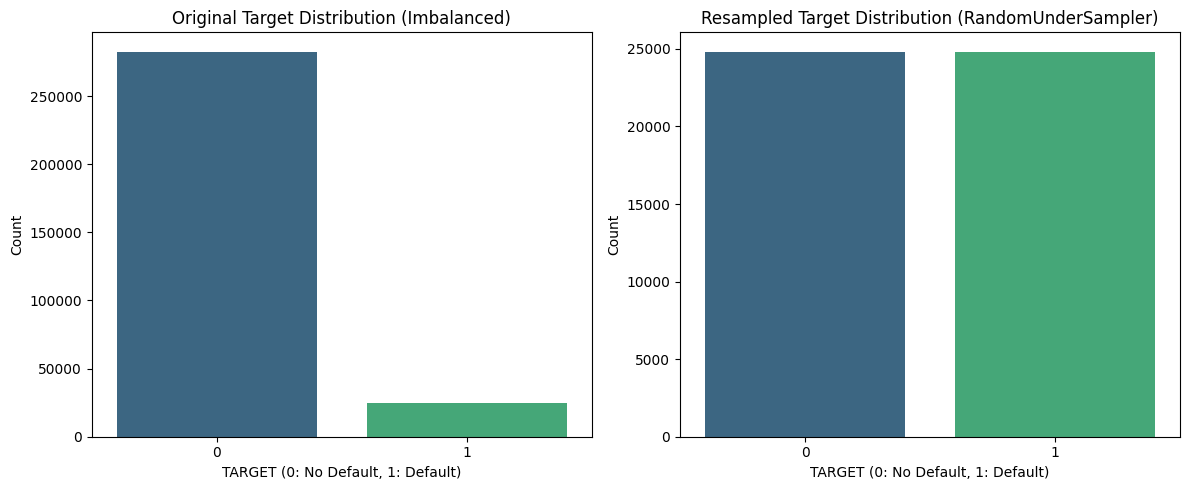

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y, palette='viridis')
plt.title('Original Target Distribution (Imbalanced)')
plt.xlabel('TARGET (0: No Default, 1: Default)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x=y_res_rus, palette='viridis')
plt.title('Resampled Target Distribution (RandomUnderSampler)')
plt.xlabel('TARGET (0: No Default, 1: Default)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42, stratify=y_res)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (395760, 245)
Shape of X_test: (169612, 245)
Shape of y_train: (395760,)
Shape of y_test: (169612,)


In [ ]:
# train a Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Calculate Sensitivity (Recall)
sensitivity = recall_score(y_test, y_pred)

print(f"Model Sensitivity (Recall): {sensitivity:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Sensitivity (Recall): 0.5673

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.60      0.59     84806
           1       0.59      0.57      0.58     84806

    accuracy                           0.58    169612
   macro avg       0.58      0.58      0.58    169612
weighted avg       0.58      0.58      0.58    169612



AUC-ROC Score: 0.6116


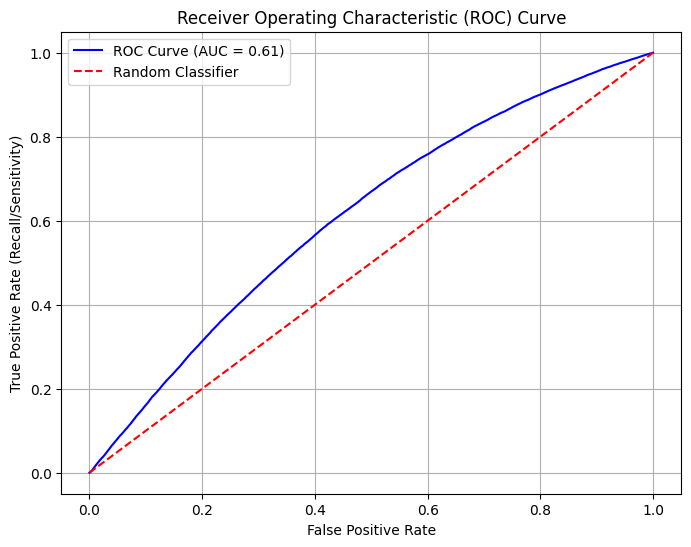

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_pred_proba = model.predict_proba(X_test)[:, 1]

auc_roc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC-ROC Score: {auc_roc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_roc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (395760, 245)
X_test_scaled shape: (169612, 245)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    # Add a Dropout layer
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Print the model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        31,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,809 (155.50 KB)

 Trainable params: 39,809 (155.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision()
                                                                     tf.keras.metrics.Recall(), tf.keras.metrics.AUC()])

In [ ]:
history = model.fit(X_train_scaled, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
9894/9894 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - accuracy: 0.9342 - auc: 0.9631 - loss: 0.1913 - precision: 0.9712 - recall: 0.8960 - val_accuracy: 0.9553 - val_auc: 0.9764 - val_loss: 0.1415 - val_precision: 0.9995 - val_recall: 0.9110
Epoch 2/10
9894/9894 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - accuracy: 0.9551 - auc: 0.9752 - loss: 0.1425 - precision: 0.9984 - recall: 0.9117 - val_accuracy: 0.9555 - val_auc: 0.9769 - val_loss: 0.1387 - val_precision: 0.9982 - val_recall: 0.9127
Epoch 3/10
9894/9894 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - accuracy: 0.9553 - auc: 0.9761 - loss: 0.1404 - precision: 0.9980 - recall: 0.9125 - val_accuracy: 0.9555 - val_auc: 0.9767 - val_loss: 0.1394 - val_precision: 0.9993 - val_recall: 0.9118
Epoch 4/10
9894/9894 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - accuracy: 0.9549 - auc: 0.9761 - loss: 0.1413 - precision: 0.9981 - recall: 0.9112 - val_accuracy: 0.9555 - val_auc: 0.9768 - val_loss: 0.1390 - val_precision: 0.9996 - val_recall: 0.9114
Epoch 5/10
9894/9894